# Anomaly Detection su Immagini Satellitari — Amazon Rainforest

**Tesi:** rilevamento anomalie (deforestazione) con Convolutional Autoencoder (unsupervised) + encoder frozen come feature extractor (supervised).

**Ambiente:** PC locale, **solo CPU**. Dataset: *Planet — Understanding the Amazon from Space* (Kaggle).

Scelte dovute alla CPU:
- Immagini ridimensionate a **128x128**.
- Modello leggero, **batch piccolo**, **subset** del dataset (non tutte le 40k immagini).
- Training piu lento: usiamo `EarlyStopping` per non sprecare tempo.

---
## Step 1 — Setup ambiente e configurazione

In [ ]:
# Import principali e configurazione globale
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.layers import (Input, Conv2D, Conv2DTranspose, Flatten, Dense, Reshape,
                          Dropout, MaxPooling2D, GlobalAveragePooling2D)
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.metrics import AUC
from keras.utils import load_img, img_to_array

# Riproducibilita: stesso seed -> stessi risultati ad ogni run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Iperparametri ---
IMG_SIZE   = 128      # lato immagine (128x128) -> piu dettaglio, ma ~4x piu lento su CPU
CHANNELS   = 3         # JPG RGB (le tif multispettrali sono opzionali, vedi nota piu sotto)
BATCH_SIZE = 32
BOTTLE_NECK = 128       # dimensione del collo di bottiglia (per t-SNE/UMAP)

# Subset del dataset per restare gestibili su CPU
N_NORMAL_TRAIN = 4000  # immagini 'normali' per addestrare il CAE
N_NORMAL_EVAL  = 1000  # normali tenute da parte per valutazione/soglia
N_ANOM_EVAL    = 1000  # immagini 'anomale' (deforestazione) per valutazione

print('TensorFlow:', tf.__version__)
print('GPU disponibili:', tf.config.list_physical_devices('GPU'), '(atteso: nessuna, siamo su CPU)')


TensorFlow: 2.21.0
GPU disponibili: [] (atteso: nessuna, siamo su CPU)


In [2]:
# Cartella per salvare modelli e figure
ART_DIR = os.path.abspath('artifacts')
os.makedirs(ART_DIR, exist_ok=True)
print('Artifacts ->', ART_DIR)


Artifacts -> c:\Users\TommasoBruzzese\OneDrive - ITS Angelo Rizzoli\Desktop\esame_ml\artifacts


## Step 2 — Download del dataset (kagglehub)

Usiamo il mirror **`nikitarom/planets-dataset`**: contiene i JPG **gia estratti** + `train_classes.csv`.

In [3]:
import kagglehub

# Scarica (o usa la cache locale se gia presente) e ritorna il path della cartella
DATASET_ROOT = kagglehub.dataset_download('nikitarom/planets-dataset')
print('Dataset scaricato in:', DATASET_ROOT)


c:\Users\TommasoBruzzese\OneDrive - ITS Angelo Rizzoli\Desktop\esame_ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset scaricato in: C:\Users\TommasoBruzzese\.cache\kagglehub\datasets\nikitarom\planets-dataset\versions\3


In [4]:
# Il layout interno del mirror puo variare: troviamo i path in modo robusto.

def find_file(root, filename):
    """Cerca ricorsivamente un file per nome e ritorna il primo match."""
    for dirpath, _, files in os.walk(root):
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

def find_dir(root, dirname):
    """Cerca ricorsivamente una cartella con immagini (la prima non vuota)."""
    candidates = []
    for dirpath, dirs, _ in os.walk(root):
        if os.path.basename(dirpath) == dirname:
            n = len(glob.glob(os.path.join(dirpath, '*.jpg')))
            if n > 0:
                candidates.append((n, dirpath))
    candidates.sort(reverse=True)  # quella con piu immagini
    return candidates[0][1] if candidates else None

CSV_PATH    = find_file(DATASET_ROOT, 'train_classes.csv')
TRAIN_JPG   = find_dir(DATASET_ROOT, 'train-jpg')

print('CSV labels :', CSV_PATH)
print('Cartella JPG:', TRAIN_JPG)
assert CSV_PATH and TRAIN_JPG, 'Path non trovati: ispeziona DATASET_ROOT con os.walk e aggiusta i nomi.'
print('N. immagini JPG:', len(glob.glob(os.path.join(TRAIN_JPG, '*.jpg'))))


CSV labels : C:\Users\TommasoBruzzese\.cache\kagglehub\datasets\nikitarom\planets-dataset\versions\3\planet\planet\train_classes.csv
Cartella JPG: C:\Users\TommasoBruzzese\.cache\kagglehub\datasets\nikitarom\planets-dataset\versions\3\planet\planet\train-jpg
N. immagini JPG: 40479


## Step 3 — Preprocessing e definizione di "normale" vs "anomalia"

Ogni immagine ha dei **tag** (multi-label). Definiamo:

- **NORMALE** = foresta intatta: ha il tag `primary` e **nessun** tag legato all'attivita umana/deforestazione.
- **ANOMALIA** = deforestazione/intervento umano: almeno uno tra `agriculture`, `cultivation`, `road`, `selective_logging`, `slash_burn`, `conventional_mine`, `artisinal_mine`, `bare_ground`, `blow_down`, `habitation`.

Il CAE viene addestrato **solo sulle NORMALI**. Le ANOMALIE servono solo in valutazione.

In [5]:
df = pd.read_csv(CSV_PATH)
df['tags_list'] = df['tags'].str.split()
print('Righe totali:', len(df))
df.head()


Righe totali: 40479


,image_name,tags,tags_list
0,train_0,haze primary,"[haze, primary]"
1,train_1,agriculture clear primary water,"[agriculture, clear, primary, water]"
2,train_2,clear primary,"[clear, primary]"
3,train_3,clear primary,"[clear, primary]"
4,train_4,agriculture clear habitation primary road,"[agriculture, clear, habitation, primary, road]"


In [6]:
# Tag che indicano deforestazione / intervento umano = ANOMALIA
ANOM_TAGS = {
    'agriculture', 'cultivation', 'road', 'selective_logging', 'slash_burn',
    'conventional_mine', 'artisinal_mine', 'bare_ground', 'blow_down', 'habitation',
}
# Tag 'meteo' (cloudy/haze/...) li ignoriamo nella definizione: non sono anomalie del suolo.

def is_normal(tags):
    s = set(tags)
    return ('primary' in s) and (len(s & ANOM_TAGS) == 0)

def is_anomaly(tags):
    return len(set(tags) & ANOM_TAGS) > 0

df['normal']  = df['tags_list'].apply(is_normal)
df['anomaly'] = df['tags_list'].apply(is_anomaly)

normals  = df[df['normal']].reset_index(drop=True)
anomalies = df[df['anomaly']].reset_index(drop=True)
print('Normali  :', len(normals))
print('Anomalie :', len(anomalies))


Normali  : 21773
Anomalie : 16325


In [ ]:
# Caricamento immagini -> array float32 in [0,1]
from keras.utils import load_img, img_to_array

def load_images(names, folder=TRAIN_JPG, size=IMG_SIZE):
    """names: lista di 'image_name' (senza estensione). Ritorna array (N, size, size, 3)."""
    out = []
    kept = []
    for nm in names:
        path = os.path.join(folder, nm + '.jpg')
        if not os.path.exists(path):
            continue
        img = load_img(path, target_size=(size, size))
        out.append(img_to_array(img))
        kept.append(nm)
    arr = np.asarray(out, dtype='float32') / 255.0
    return arr, kept


In [8]:
# Campioniamo i subset (shuffle deterministico via SEED)
norm_names = normals['image_name'].sample(frac=1, random_state=SEED).tolist()
anom_names = anomalies['image_name'].sample(frac=1, random_state=SEED).tolist()

train_names = norm_names[:N_NORMAL_TRAIN]
eval_norm_names = norm_names[N_NORMAL_TRAIN:N_NORMAL_TRAIN + N_NORMAL_EVAL]
eval_anom_names = anom_names[:N_ANOM_EVAL]

print('Carico immagini... (puo richiedere qualche minuto la prima volta)')
X_train_full, _ = load_images(train_names)
X_eval_norm, _  = load_images(eval_norm_names)
X_eval_anom, _  = load_images(eval_anom_names)
print('Train normali :', X_train_full.shape)
print('Eval normali  :', X_eval_norm.shape)
print('Eval anomalie :', X_eval_anom.shape)


Carico immagini... (puo richiedere qualche minuto la prima volta)
Train normali : (4000, 128, 128, 3)
Eval normali  : (1000, 128, 128, 3)
Eval anomalie : (1000, 128, 128, 3)


In [9]:
# Split train/validation (solo normali: il CAE non vede mai anomalie in training)
n_val = int(0.1 * len(X_train_full))
X_val   = X_train_full[:n_val]
X_train = X_train_full[n_val:]
print('Train:', X_train.shape, '| Val:', X_val.shape)


Train: (3600, 128, 128, 3) | Val: (400, 128, 128, 3)


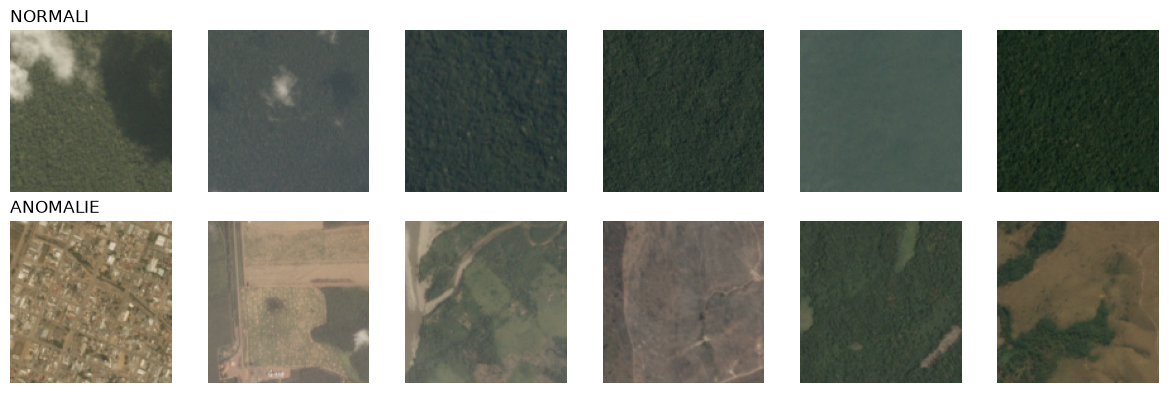

In [10]:
# Sanity check visivo: alcune normali vs alcune anomalie
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(X_train[i]); axes[0, i].axis('off')
    axes[1, i].imshow(X_eval_anom[i]); axes[1, i].axis('off')
axes[0, 0].set_title('NORMALI', loc='left')
axes[1, 0].set_title('ANOMALIE', loc='left')
plt.tight_layout(); plt.show()


## Step 4 — Convolutional Autoencoder (CAE) in Keras

Architettura encoder–decoder simmetrica:
- **Encoder**: 4 blocchi Conv stride-2 (64→32→16→8→4) → `Dense(LATENT_DIM)`.
- **Decoder**: `Dense` → reshape → 4 blocchi Conv2DTranspose stride-2 → immagine 64×64×3.

Il `Dense(LATENT_DIM)` e il **collo di bottiglia** che useremo per t-SNE/UMAP e come feature extractor (Parte 2).

In [ ]:
# ENCODER come sotto-modello (riusabile come feature extractor nella Parte 2)
encoder = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    Conv2D(32,  3, strides=2, padding='same', activation='leaky_relu'),
    Conv2D(64,  3, strides=2, padding='same', activation='leaky_relu'),
    Conv2D(128, 3, strides=2, padding='same', activation='leaky_relu'),
    Conv2D(256, 3, strides=2, padding='same', activation='leaky_relu'),
    Flatten(),
    Dense(BOTTLE_NECK, activation='leaky_relu'),
], name='encoder')

# Dimensione spaziale dopo i 4 downsample stride-2: IMG_SIZE / 2^4
FEAT = IMG_SIZE // 16   # downsample 2^4: 64->4, 128->8

# DECODER come sotto-modello
decoder = Sequential([
    Input(shape=(BOTTLE_NECK,)),
    Dense(FEAT * FEAT * 256, activation='leaky_relu'),
    Reshape((FEAT, FEAT, 256)),
    Conv2DTranspose(128, 3, strides=2, padding='same', activation='leaky_relu'),
    Conv2DTranspose(64,  3, strides=2, padding='same', activation='leaky_relu'),
    Conv2DTranspose(32,  3, strides=2, padding='same', activation='leaky_relu'),
    Conv2DTranspose(32,  3, strides=2, padding='same', activation='leaky_relu'),
    Conv2D(CHANNELS, 3, padding='same', activation='sigmoid'),
], name='decoder')

autoencoder = Sequential([encoder, decoder], name='CAE')

autoencoder.compile(optimizer = Adam(1e-3), loss='mse')
autoencoder.summary()


Model: "CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 128)            │     2,485,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 128, 128, 3)    │     2,510,947 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,996,643 (19.06 MB)

 Trainable params: 4,996,643 (19.06 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Training del CAE

Obiettivo: ricostruire l'input (`X -> X`). `EarlyStopping` ferma il training quando la val loss smette di migliorare (risparmio tempo su CPU). `ModelCheckpoint` salva il modello migliore.

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(os.path.join(ART_DIR, 'cae_best.keras'),
                                    monitor='val_loss', save_best_only=True),
]

model = autoencoder.fit(
    X_train, X_train,                 # input = target (ricostruzione)
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 42s 340ms/step - loss: 0.0172 - val_loss: 0.0030
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 344ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 337ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 339ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 318ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 320ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 9/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 333ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 10/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 39s 340ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 11/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 38s 336ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 12/50
113/113

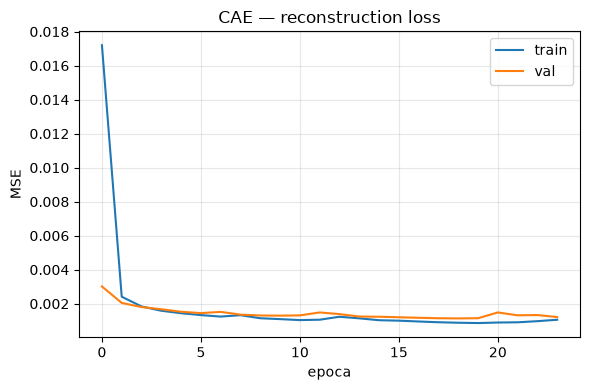

In [13]:
# Curva di loss
plt.figure(figsize=(6, 4))
plt.plot(model.history['loss'], label='train')
plt.plot(model.history['val_loss'], label='val')
plt.xlabel('epoca'); plt.ylabel('MSE'); plt.title('CAE — reconstruction loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(ART_DIR, 'loss_curve.png'), dpi=120); plt.show()


## Step 6 — Anomaly detection via errore di ricostruzione

Idea: il CAE ricostruisce bene cio che ha imparato (foresta normale) e **male** le anomalie. 
L'errore di ricostruzione (MSE pixel-wise) e quindi un **anomaly score**: alto = probabile anomalia.

Per la soglia confrontiamo due criteri: **p95** dei normali (conservativa) e quella che **massimizza l'F1** 
(sweep sulla precision-recall curve). L'AUROC e indipendente dalla soglia.

In [14]:
def recon_error(model, X, batch=128):
    """MSE medio per immagine (un valore per immagine)."""
    recon = model.predict(X, batch_size=batch, verbose=0)
    return np.mean((X - recon) ** 2, axis=(1, 2, 3)), recon

err_norm, _ = recon_error(autoencoder, X_eval_norm)
err_anom, _ = recon_error(autoencoder, X_eval_anom)
print('MSE normali  -> media %.5f' % err_norm.mean())
print('MSE anomalie -> media %.5f' % err_anom.mean())


MSE normali  -> media 0.00111
MSE anomalie -> media 0.00265


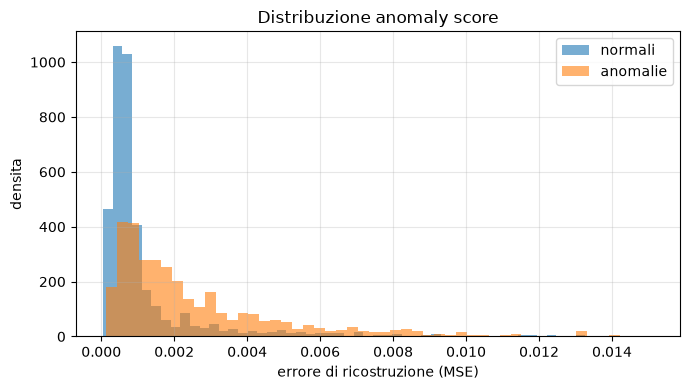

In [15]:
# Distribuzione degli errori: separazione tra normali e anomalie
plt.figure(figsize=(7, 4))
plt.hist(err_norm, bins=50, alpha=0.6, label='normali', density=True)
plt.hist(err_anom, bins=50, alpha=0.6, label='anomalie', density=True)
plt.xlabel('errore di ricostruzione (MSE)'); plt.ylabel('densita')
plt.title('Distribuzione anomaly score'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(ART_DIR, 'score_hist.png'), dpi=120); plt.show()


In [16]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_recall_curve

# y=1 anomalia, y=0 normale. score = errore di ricostruzione.
y_true  = np.concatenate([np.zeros(len(err_norm)), np.ones(len(err_anom))])
y_score = np.concatenate([err_norm, err_anom])

auroc = roc_auc_score(y_true, y_score)
print('AUROC (unsupervised, solo CAE): %.3f' % auroc)

# --- Soglia A: percentile 95 dei normali (conservativa, pochi falsi allarmi) ---
thr_p95 = np.percentile(err_norm, 95)
f1_p95  = f1_score(y_true, (y_score > thr_p95).astype(int))
print('Soglia p95   = %.5f  -> F1 = %.3f' % (thr_p95, f1_p95))

# --- Soglia B: quella che MASSIMIZZA l'F1 (sweep su tutti i candidati) ---
prec, rec, thr_pr = precision_recall_curve(y_true, y_score)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best = np.argmax(f1_curve[:-1])          # ultimo elemento non ha soglia associata
thr_best = thr_pr[best]
print('Soglia bestF1 = %.5f  -> F1 = %.3f  (Precision=%.3f  Recall=%.3f)'
      % (thr_best, f1_curve[best], prec[best], rec[best]))

# Usiamo la soglia ottimale come riferimento
thr = thr_best
y_pred = (y_score > thr).astype(int)


AUROC (unsupervised, solo CAE): 0.777
Soglia p95   = 0.00403  -> F1 = 0.323
Soglia bestF1 = 0.00073  -> F1 = 0.744  (Precision=0.672  Recall=0.833)


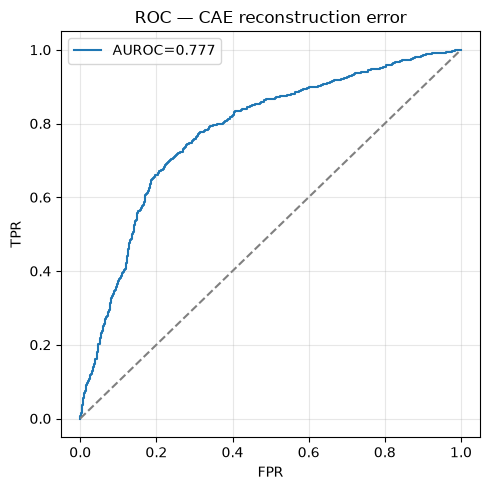

In [17]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='AUROC=%.3f' % auroc)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — CAE reconstruction error')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(ART_DIR, 'roc_cae.png'), dpi=120); plt.show()


### Mappe di anomalia (visualizzazione)

L'errore **per pixel** (non mediato) mostra *dove* la ricostruzione fallisce → heatmap delle zone anomale (deforestazione, strade, ecc.).

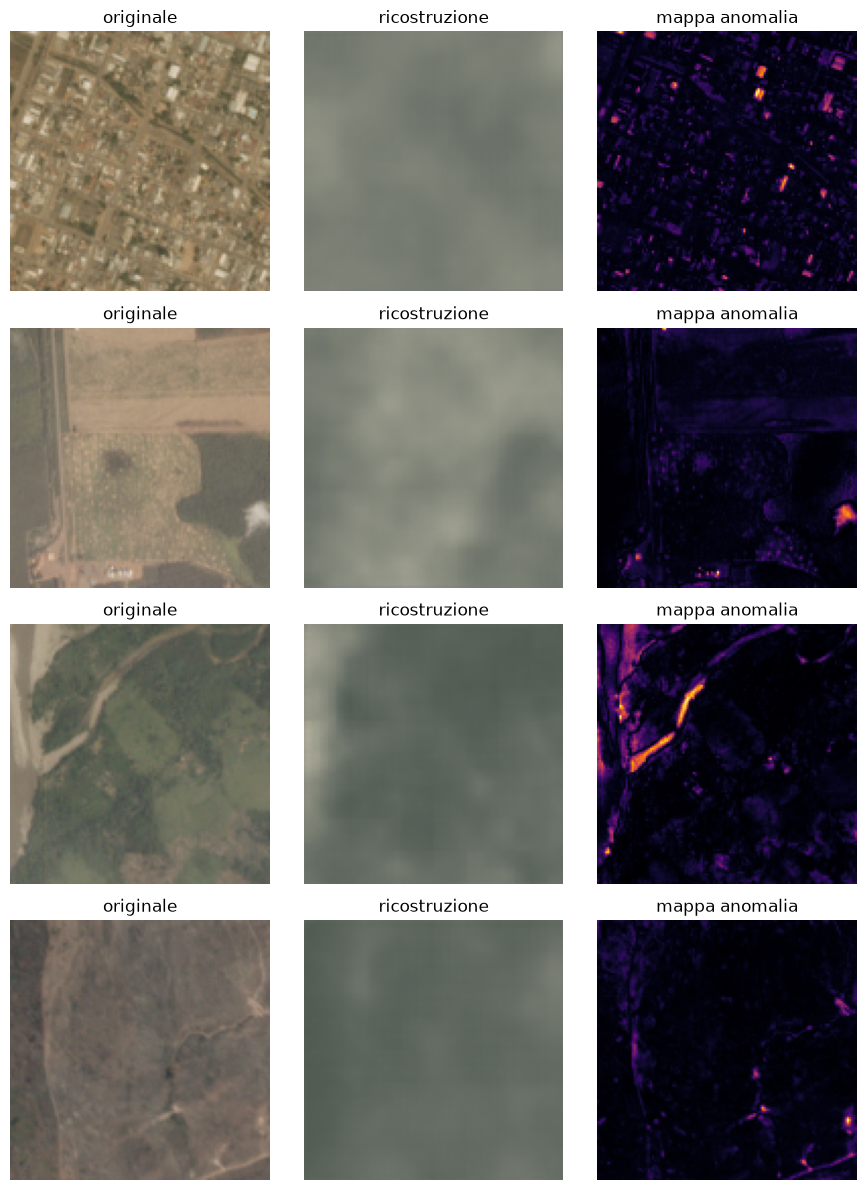

In [ ]:
def anomaly_map(model, img):
    recon = model.predict(img[None, ...], verbose=0)[0]
    amap = np.mean((img - recon) ** 2, axis=-1)
    return recon, amap

samples = X_eval_anom[:4]
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, im in enumerate(samples):
    recon, amap = anomaly_map(autoencoder, im)
    axes[i, 0].imshow(im); axes[i, 0].set_title('originale'); axes[i, 0].axis('off')
    axes[i, 1].imshow(recon); axes[i, 1].set_title('ricostruzione'); axes[i, 1].axis('off')
    axes[i, 2].imshow(amap, cmap='inferno'); axes[i, 2].set_title('mappa anomalia'); axes[i, 2].axis('off')
plt.tight_layout(); plt.savefig(os.path.join(ART_DIR, 'anomaly_maps.png'), dpi=120); plt.show()


## Step 7 — Visualizzazione del latent space (t-SNE / UMAP)

Proiettiamo il vettore latente (`LATENT_DIM`) in 2D. Se il CAE ha imparato struttura utile, normali e anomalie dovrebbero separarsi parzialmente — pur non avendo mai visto le anomalie in training.

In [ ]:
N_VIZ = 800
Xv_norm = X_eval_norm[:N_VIZ]
Xv_anom = X_eval_anom[:N_VIZ]
Z_norm = encoder.predict(Xv_norm, batch_size=128, verbose=0)
Z_anom = encoder.predict(Xv_anom, batch_size=128, verbose=0)
Z = np.concatenate([Z_norm, Z_anom])
labels = np.concatenate([np.zeros(len(Z_norm)), np.ones(len(Z_anom))])
print('Latenti:', Z.shape)


Latenti: (1600, 128)


In [20]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go

Z3 = TSNE(n_components=3, perplexity=30, random_state=SEED, init='pca').fit_transform(Z)

fig = go.Figure()
for lab, name, col in [(0, 'normali', 'royalblue'), (1, 'anomalie', 'crimson')]:
    m = labels == lab
    fig.add_trace(go.Scatter3d(
        x=Z3[m, 0], y=Z3[m, 1], z=Z3[m, 2],
        mode='markers', name=name,
        marker=dict(size=3, color=col, opacity=0.6)))
fig.update_layout(
    title='t-SNE 3D del latent space del CAE',
    scene=dict(xaxis_title='dim 1', yaxis_title='dim 2', zaxis_title='dim 3'),
    width=800, height=700, legend=dict(itemsizing='constant'))
fig.write_html(os.path.join(ART_DIR, 'tsne_latent_3d.html'))
fig.show()

In [21]:
# UMAP opzionale (richiede 'umap-learn'). Salta in silenzio se non installato.
try:
    import umap
    import plotly.graph_objects as go
    Zu = umap.UMAP(n_components=3, random_state=SEED).fit_transform(Z)
    fig = go.Figure()
    for lab, name, col in [(0, 'normali', 'royalblue'), (1, 'anomalie', 'crimson')]:
        m = labels == lab
        fig.add_trace(go.Scatter3d(
            x=Zu[m, 0], y=Zu[m, 1], z=Zu[m, 2],
            mode='markers', name=name,
            marker=dict(size=3, color=col, opacity=0.6)))
    fig.update_layout(
        title='UMAP 3D del latent space del CAE',
        scene=dict(xaxis_title='dim 1', yaxis_title='dim 2', zaxis_title='dim 3'),
        width=800, height=700, legend=dict(itemsizing='constant'))
    fig.write_html(os.path.join(ART_DIR, 'umap_latent_3d.html'))
    fig.show()
except ImportError:
    print('umap-learn non installato: salto (la t-SNE sopra e sufficiente).')

c:\Users\TommasoBruzzese\OneDrive - ITS Angelo Rizzoli\Desktop\esame_ml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Parte 2 — Supervised: encoder frozen come feature extractor

Riusiamo l'**encoder gia addestrato** (congelato) come estrattore di feature e ci mettiamo sopra un piccolo classificatore binario (normale vs anomalia). Poi confrontiamo con una **CNN from scratch** addestrata end-to-end.

Metriche: **AUROC, F1, Precision/Recall**.

In [22]:
from sklearn.model_selection import train_test_split

# Dataset etichettato bilanciato: normali (0) + anomalie (1)
X_sup = np.concatenate([X_eval_norm, X_eval_anom])
y_sup = np.concatenate([np.zeros(len(X_eval_norm)), np.ones(len(X_eval_anom))]).astype('float32')

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_sup, y_sup, test_size=0.3, stratify=y_sup, random_state=SEED)
print('Train sup:', Xs_tr.shape, '| Test sup:', Xs_te.shape)


Train sup: (1400, 128, 128, 3) | Test sup: (600, 128, 128, 3)


In [23]:
# Encoder congelato + testa di classificazione
encoder.trainable = False   # FROZEN: i pesi del CAE non si aggiornano

clf_frozen = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    encoder,                                # feature extractor latente (frozen)
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
], name='clf_frozen_encoder')

clf_frozen.compile(optimizer=Adam(1e-3),
                   loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

h_frozen = clf_frozen.fit(
    Xs_tr, ys_tr, validation_split=0.2,
    epochs=50, batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max',
                                             patience=8, restore_best_weights=True)],
    verbose=1)

# Salva le predizioni del modello SOLO-frozen prima del fine-tuning (per confronto)
pred_frozen_only = clf_frozen.predict(Xs_te, verbose=0).ravel()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6554 - auc: 0.7017 - loss: 0.6385 - val_accuracy: 0.6964 - val_auc: 0.7435 - val_loss: 0.6385
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7232 - auc: 0.7884 - loss: 0.5733 - val_accuracy: 0.7036 - val_auc: 0.7480 - val_loss: 0.6487
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7250 - auc: 0.7943 - loss: 0.5649 - val_accuracy: 0.6964 - val_auc: 0.7500 - val_loss: 0.6512
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7277 - auc: 0.8030 - loss: 0.5514 - val_accuracy: 0.7179 - val_auc: 0.7540 - val_loss: 0.6504
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7402 - auc: 0.8069 - loss: 0.5462 - val_accuracy: 0.7036 - val_auc: 0.7583 - val_loss: 0.6531
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7420 - auc: 0.8169 - loss: 0.5351 - val_accuracy: 0.6964 - val_auc: 0.7620 - val_loss: 0.6483
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/

### Fine-tuning dell'encoder

L'encoder frozen rende poco perche il CAE e ottimizzato per *ricostruire*, non per *discriminare*. 
Lo **sblocchiamo** e continuiamo il training con learning rate basso (`1e-4`): le feature si adattano al task di classificazione senza distruggere quanto appreso dal CAE.

In [24]:
# Fine-tuning: sblocchiamo l'encoder e continuiamo con learning rate BASSO.
# Parte dai pesi del classificatore frozen gia addestrato -> adatta le feature al task.
encoder.trainable = True   # sblocca

clf_frozen.compile(optimizer=Adam(1e-4),   # LR basso = non distrugge i pesi pre-addestrati
                   loss='binary_crossentropy',
                   metrics=['accuracy', AUC(name='auc')])

h_finetune = clf_frozen.fit(
    Xs_tr, ys_tr, validation_split=0.2,
    epochs=40, batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max',
                                             patience=8, restore_best_weights=True)],
    verbose=1)

clf_finetune = clf_frozen   # alias: stesso modello, ora fine-tuned


Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.8339 - auc: 0.9011 - loss: 0.4063 - val_accuracy: 0.7393 - val_auc: 0.8003 - val_loss: 0.7280
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.8482 - auc: 0.9198 - loss: 0.3625 - val_accuracy: 0.7536 - val_auc: 0.8122 - val_loss: 0.7131
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8589 - auc: 0.9292 - loss: 0.3369 - val_accuracy: 0.7714 - val_auc: 0.8188 - val_loss: 0.6948
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8652 - auc: 0.9374 - loss: 0.3217 - val_accuracy: 0.7500 - val_auc: 0.8166 - val_loss: 0.7425
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8643 - auc: 0.9378 - loss: 0.3190 - val_accuracy: 0.7679 - val_auc: 0.8198 - val_loss: 0.7313
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8866 - auc: 0.9456 - loss: 0.2961 - val_accuracy: 0.7714 - val_auc: 0.8270 - val_loss: 0.7337
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 

In [ ]:
cnn = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    Conv2D(32,  3, activation='relu', padding='same'),
    MaxPooling2D(),
    Conv2D(64,  3, activation='relu', padding='same'),
    
    MaxPooling2D(),
    Conv2D(128, 3, activation='relu', padding='same'),
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
], name='cnn_scratch')
cnn.compile(optimizer=Adam(1e-3),
            loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

h_cnn = cnn.fit(
    Xs_tr, ys_tr, validation_split=0.2,
    epochs=50, batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max',
                                             patience=8, restore_best_weights=True)],
    verbose=1)


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.5723 - auc: 0.6463 - loss: 0.6709 - val_accuracy: 0.6964 - val_auc: 0.7694 - val_loss: 0.6096
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - accuracy: 0.7143 - auc: 0.7548 - loss: 0.5920 - val_accuracy: 0.7107 - val_auc: 0.7873 - val_loss: 0.5647
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.7304 - auc: 0.7822 - loss: 0.5655 - val_accuracy: 0.7071 - val_auc: 0.7997 - val_loss: 0.5524
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.7446 - auc: 0.7859 - loss: 0.5565 - val_accuracy: 0.7000 - val_auc: 0.8053 - val_loss: 0.5464
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.7491 - auc: 0.8086 - loss: 0.5378 - val_accuracy: 0.7143 - val_auc: 0.8183 - val_loss: 0.5451
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.7545 - auc: 0.8179 - loss: 0.5264 - val_accuracy: 0.7357 - val_auc: 0.8169 - val_loss: 0.5310
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s

In [26]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

def metrics_from_scores(scores, name):
    pred = (scores > 0.5).astype(int)
    auc = roc_auc_score(ys_te, scores)
    pr, rc, f1, _ = precision_recall_fscore_support(ys_te, pred, average='binary')
    print('=== %s ===' % name)
    print('AUROC=%.3f  F1=%.3f  Precision=%.3f  Recall=%.3f' % (auc, f1, pr, rc))
    print(classification_report(ys_te, pred, target_names=['normale', 'anomalia']))
    return dict(name=name, auroc=auc, f1=f1, precision=pr, recall=rc, scores=scores)

res_frozen   = metrics_from_scores(pred_frozen_only, 'Encoder frozen + classificatore')
res_finetune = metrics_from_scores(clf_finetune.predict(Xs_te, verbose=0).ravel(), 'Encoder fine-tuned + classificatore')
res_cnn      = metrics_from_scores(cnn.predict(Xs_te, verbose=0).ravel(), 'CNN from scratch')


=== Encoder frozen + classificatore ===
AUROC=0.811  F1=0.738  Precision=0.781  Recall=0.700
              precision    recall  f1-score   support

     normale       0.73      0.80      0.76       300
    anomalia       0.78      0.70      0.74       300

    accuracy                           0.75       600
   macro avg       0.75      0.75      0.75       600
weighted avg       0.75      0.75      0.75       600

=== Encoder fine-tuned + classificatore ===
AUROC=0.843  F1=0.767  Precision=0.789  Recall=0.747
              precision    recall  f1-score   support

     normale       0.76      0.80      0.78       300
    anomalia       0.79      0.75      0.77       300

    accuracy                           0.77       600
   macro avg       0.77      0.77      0.77       600
weighted avg       0.77      0.77      0.77       600

=== CNN from scratch ===
AUROC=0.875  F1=0.764  Precision=0.840  Recall=0.700
              precision    recall  f1-score   support

     normale       0.74

                               name    auroc       f1  precision   recall
    Encoder frozen + classificatore 0.810800 0.738137   0.780669 0.700000
Encoder fine-tuned + classificatore 0.843322 0.767123   0.788732 0.746667
                   CNN from scratch 0.875022 0.763636   0.840000 0.700000


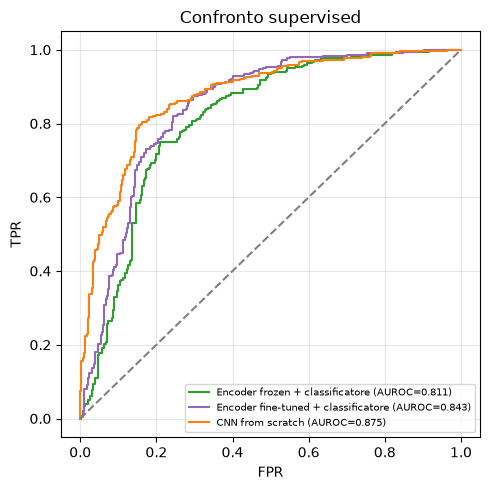

In [27]:
# Tabella di confronto + ROC sovrapposte
comp = pd.DataFrame([res_frozen, res_finetune, res_cnn])[['name', 'auroc', 'f1', 'precision', 'recall']]
print(comp.to_string(index=False))

plt.figure(figsize=(5, 5))
for res, col in [(res_frozen, 'tab:green'), (res_finetune, 'tab:purple'), (res_cnn, 'tab:orange')]:
    fpr, tpr, _ = roc_curve(ys_te, res['scores'])
    plt.plot(fpr, tpr, color=col, label='%s (AUROC=%.3f)' % (res['name'], res['auroc']))
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Confronto supervised')
plt.legend(fontsize=7); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(ART_DIR, 'roc_supervised.png'), dpi=120); plt.show()
